In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
from tqdm import tqdm
import os
import cv2
import matplotlib.pyplot as plt

data_dir="/kaggle/input/animals-detection-images-dataset"
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

all_train_subdir=glob.glob(train_dir+"/*")
all_test_subdir=glob.glob(test_dir+"/*")

# 1. Exploratory Data Analysis

How many classes in the datasets? How many images in each class? Let's have a look

In [5]:
train_classes=[os.path.basename(pp) for pp in all_train_subdir]
test_classes=[os.path.basename(pp) for pp in all_test_subdir]

print("There is %d classes in train dataset, and %d classes in test dataset"%(len(train_classes), len(test_classes)))


There is 80 classes in train dataset, and 80 classes in test dataset


Ensure train dataset and val dataset have same classes

In [6]:
train_classes==test_classes

True

Now create pandas DataFrames, so we can clear watch the detail

In [7]:

train_image_counts={os.path.basename(pp):[len(glob.glob(os.path.join(pp, "*.jpg")))] for pp in all_train_subdir}
test_image_counts={os.path.basename(pp):[len(glob.glob(os.path.join(pp, "*.jpg")))] for pp in all_test_subdir}
# all_image_counts=train_image_counts.copy()
# all_image_counts={k:all_image_counts[k]+test_image_counts[k] for k in all_image_counts.keys()}
train_data_df = pd.DataFrame(train_image_counts, index=["train"]).transpose()
test_data_df = pd.DataFrame(test_image_counts, index=["test"]).transpose()
all_data_df=train_data_df.copy()
all_data_df["test"]=test_data_df
all_data_df.head()

,train,test
Spider,856,207
Parrot,421,180
Scorpion,80,44
Sea turtle,239,87
Cattle,70,171


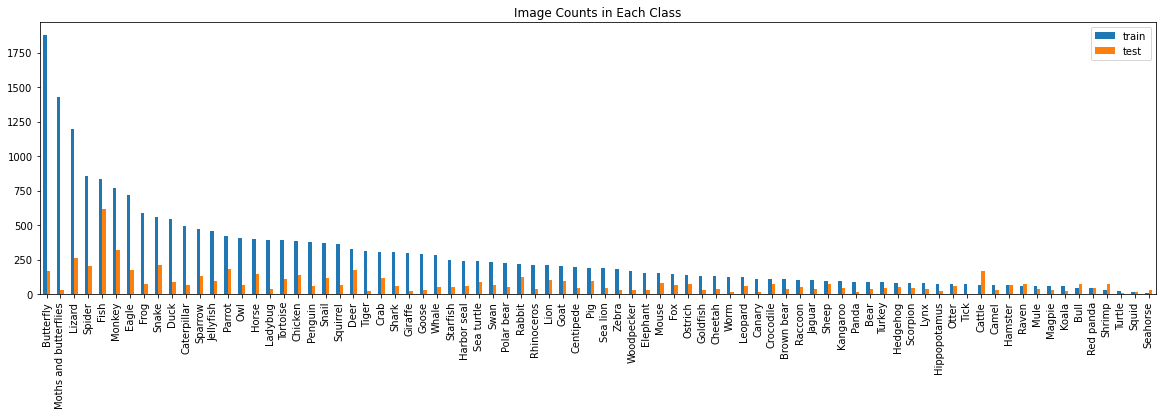

In [8]:

all_data_df=all_data_df.sort_values(by=["train","test"], ascending=False)
all_data_df.plot(kind="bar", legend=True, figsize=(20,5), title="Image Counts in Each Class");

This is a typical long-tail dataset. What about the image size? Let's have a look

In [9]:
!apt-get install -y file

Reading package lists... Done
Building dependency tree       
Reading state information... Done
file is already the newest version (1:5.32-2ubuntu0.4).
file set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 19 not upgraded.


In [10]:
os.makedirs("output", exist_ok=True)
!file /kaggle/input/animals-detection-images-dataset/train/Spider/*.jpg|awk '{print $18}'|sort|uniq |wc -l

317


In [11]:
!file /kaggle/input/animals-detection-images-dataset/test/Spider/*.jpg|awk '{print $18}'|sort|uniq |wc -l

98


So we know there are 317 different image sizes in train dataset, and 98 in test dataset.

Let's watch some images

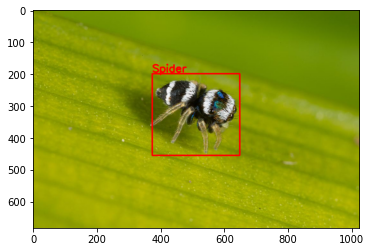

In [25]:
def draw_image(image_file, label_file, class_names):
    class_name = os.path.basename(os.path.dirname(image_file))    
    image = cv2.imread(image_file)
        
    with open(label_file) as fobj:
        while True:            
            item = fobj.readline()
            if item is None or len(item)<=0:
                break
                
            item = item[len(class_name):]
            item = item.split()
            xmin = float(item[0])
            ymin = float(item[1])
            xmax = float(item[2])
            ymax = float(item[3])
        
            image = cv2.rectangle(image, (int(xmin), int(ymin)), (int(xmax), int(ymax)), (0,0,255), 3)
            image = cv2.putText(image, class_name, (int(xmin), int(ymin-5)), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 3)
        
    return image

subdir = all_train_subdir[0]
image_files = glob.glob(os.path.join(subdir, "*.jpg"))

image_file = image_files[0]
label_file = os.path.join(subdir, "Label", os.path.basename(image_file).replace(".jpg", ".txt"))

image = draw_image(image_file, label_file, train_classes)
image = image[:,:,2::-1]
plt.imshow(image);

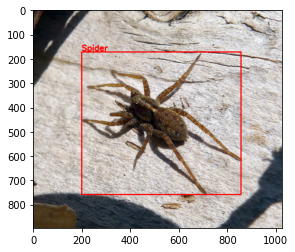

In [26]:
image_file = image_files[45]
label_file = os.path.join(subdir, "Label", os.path.basename(image_file).replace(".jpg", ".txt"))
image = draw_image(image_file, label_file, train_classes)
image = image[:,:,2::-1]
plt.imshow(image);

# 2. Create yolo dataset

In [27]:
yolo_train_dir = "yolo/train"
yolo_test_dir = "yolo/test"

for dd in [yolo_train_dir, yolo_test_dir]:
    for ss in ["images", "labels"]:
        print(os.path.join(dd, ss))
        os.makedirs(os.path.join(dd, ss), exist_ok=True)

yolo/train/images
yolo/train/labels
yolo/test/images
yolo/test/labels


In [28]:
yolo_train_dir = "yolo2/train"
yolo_test_dir = "yolo2/test"

for dd in [yolo_train_dir, yolo_test_dir]:
    for ss in ["images", "labels"]:
        print(os.path.join(dd, ss))
        os.makedirs(os.path.join(dd, ss), exist_ok=True)

yolo2/train/images
yolo2/train/labels
yolo2/test/images
yolo2/test/labels


In [29]:
for subdir_id in tqdm(range(len(all_train_subdir))):
    subdir = all_train_subdir[subdir_id]

100%|██████████| 80/80 [00:00<00:00, 488419.68it/s]


In [ ]:
"%s_%s"%("hawk","xueqin")



In [30]:
def process_dataset(subdirs, dst_dir, class_names, size=(640,640), link=False):
    for subdir_id in tqdm(range(len(subdirs))):
        subdir = subdirs[subdir_id]
        prefix=os.path.basename(subdir)
        for image_file in glob.glob(os.path.join(subdir, "*.jpg")):
            image_file_basename=os.path.basename(image_file)
            label_file = os.path.join(subdir, "Label", image_file_basename).replace(".jpg", ".txt")
            dst_image_file = os.path.join(dst_dir, "images/%s_%s"%(prefix,image_file_basename))
            dst_label_file = os.path.join(dst_dir, "labels/%s_%s"%(prefix,image_file_basename.replace(".jpg", ".txt")))
            if os.path.exists(dst_label_file):
                continue
                        
            image = cv2.imread(image_file)                
            height, width = image.shape[0:2]
            with open(label_file) as fobj:
                with open(dst_label_file, "w") as wobj:
                    while True:
                        item = fobj.readline()
                        if item is None or len(item)==0:
                            break
                        class_name = prefix
                        item=item[len(class_name):]
                        item = item.split()
                        xmin = float(item[0])
                        ymin = float(item[1])
                        xmax = float(item[2])
                        ymax = float(item[3])

                        cx   = (xmin + xmax)/2.0/width
                        cy   = (ymin + ymax)/2.0/height
                        bw   = (xmax - xmin)/width
                        bh   = (ymax - ymin)/height
                        class_id = class_names.index(class_name)
                        output_line = "%d %f %f %f %f\n"%(class_id, cx, cy, bw, bh)
                        wobj.write(output_line)

            if link==True:
                os.symlink(image_file, dst_image_file)
            else:
                image = cv2.resize(image, size)
                cv2.imwrite(dst_image_file, image)

# process_dataset(all_train_subdir, yolo_train_dir, train_classes, size=(640,640), link=False)        
xueqin_train_subdir=all_train_subdir[0:1]
xueqin_classes=[os.path.basename(pp) for pp in xueqin_train_subdir]

process_dataset(xueqin_train_subdir, yolo_train_dir, xueqin_classes, size=(640,640), link=False)        

100%|██████████| 1/1 [00:26<00:00, 26.17s/it]


In [31]:
xueqin_test_subdir=all_test_subdir[0:1]
process_dataset(xueqin_test_subdir, yolo_test_dir, xueqin_classes, size=(640,640), link=False)        

100%|██████████| 1/1 [00:06<00:00,  6.40s/it]


In [32]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
%pip install -r requirements.txt
%cd -

Cloning into 'yolov5'...
remote: Enumerating objects: 7091, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 7091 (delta 106), reused 117 (delta 63), pack-reused 6894
Receiving objects: 100% (7091/7091), 9.13 MiB | 20.55 MiB/s, done.
Resolving deltas: 100% (4842/4842), done.
/kaggle/working/yolov5
Note: you may need to restart the kernel to use updated packages.
/kaggle/working


In [33]:
!cat yolov5/data/coco128.yaml

# COCO 2017 dataset http://cocodataset.org - first 128 training images
# Train command: python train.py --data coco128.yaml
# Default dataset location is next to YOLOv5:
#   /parent_folder
#     /coco128
#     /yolov5


# download command/URL (optional)
download: https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip

# train and val data as 1) directory: path/images/, 2) file: path/images.txt, or 3) list: [path1/images/, path2/images/]
train: ../coco128/images/train2017/  # 128 images
val: ../coco128/images/train2017/  # 128 images

# number of classes
nc: 80

# class names
names: [ 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
         'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
         'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
         'skis', 'snowboard', 'sports ball', 'kite', 'baseball

In [34]:
yaml_file="yolov5/data/animal.yaml"
train_images_dir = os.path.join("..", yolo_train_dir, "images")
val_images_dir = os.path.join("..", yolo_test_dir, "images")


names_str=""
for item in xueqin_classes:
    names_str=names_str + ", \'%s\'"%item
names_str= "names: ["+names_str[1:]+"]"

with open(yaml_file, "w") as wobj:
    wobj.write("train: %s\n"%train_images_dir)
    wobj.write("val: %s\n"%val_images_dir)
    wobj.write("nc: %d\n"%len(xueqin_classes))
    wobj.write(names_str+"\n")
    

In [35]:
import wandb
wandb.login()

wandb: You can find your API key in your browser here: https://wandb.ai/authorize


wandb: Paste an API key from your profile and hit enter:  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [37]:
%cd yolov5
!bash weights/download_weights.sh

/kaggle/working/yolov5
100%|██████████████████████████████████████| 14.1M/14.1M [00:00<00:00, 39.2MB/s]

100%|██████████████████████████████████████| 41.1M/41.1M [00:00<00:00, 73.4MB/s]

100%|██████████████████████████████████████| 90.2M/90.2M [00:01<00:00, 78.0MB/s]

100%|████████████████████████████████████████| 168M/168M [00:02<00:00, 86.7MB/s]



In [38]:
!mv *.pt weights
!ls weights

download_weights.sh  yolov5l.pt  yolov5m.pt  yolov5s.pt  yolov5x.pt


In [40]:
!python train.py --data data/animal.yaml --batch-size 32 --epochs 10 --img-size 640 --project runs/train --name animals --weights weights/yolov5s.pt --device 0

github: up to date with https://github.com/ultralytics/yolov5 ✅
2021-06-11 10:26:43.562404: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
wandb: Currently logged in as: hawkwang (use `wandb login --relogin` to force relogin)
wandb: wandb version 0.10.32 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
2021-06-11 10:26:46.533445: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2021-06-11 10:26:46.535978: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
wandb: Tracking run with wandb version 0.10.26
wandb: Syncing run animals2
wandb: ⭐️ View project at https://wandb.ai/hawkwang/YOLOv5
wandb: 🚀 View run at https://wandb.ai/hawkwang/YOLOv5/runs/3a7pzbzh
wandb: Run data is saved locally in /kaggle/working/yolov5/wandb/run-20210611_102645-3a7pzbzh
wandb: Ru

In [61]:
!python detect.py --weights runs/train/animals2/weights/best.pt --source /kaggle/input/animals-detection-images-dataset/test/Spider/5b9b0b60d04aae25.jpg --name animals --project runs/detect

Namespace(agnostic_nms=False, augment=False, classes=None, conf_thres=0.25, device='', exist_ok=False, half=False, hide_conf=False, hide_labels=False, imgsz=640, iou_thres=0.45, line_thickness=3, max_det=1000, name='animals', nosave=False, project='runs/detect', save_conf=False, save_crop=False, save_txt=False, source='/kaggle/input/animals-detection-images-dataset/test/Spider/5b9b0b60d04aae25.jpg', update=False, view_img=False, weights=['runs/train/animals2/weights/best.pt'])
image 1/1 /kaggle/input/animals-detection-images-dataset/test/Spider/5b9b0b60d04aae25.jpg: 480x640 1 Spider, Done. (0.028s)
Results saved to runs/detect/animals
Done. (0.073s)


In [57]:
!mkdir -p tmp
!cp runs/train/animals2/test_batch0_labels.jpg tmp/0.jpg
!cp runs/train/animals2/test_batch0_pred.jpg tmp/1.jpg
!ffmpeg -r 1 -i tmp/%d.jpg -r 1 -y tmp/out.gif

ffmpeg version 4.3.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 9.3.0 (crosstool-NG 1.24.0.133_b0863d8_dirty)
  configuration: --prefix=/opt/conda --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1609680890771/_build_env/bin/x86_64-conda-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-gpl --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-libx264 --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --pkg-config=/home/conda/feedstock_root/build_artifacts/ffmpeg_1609680890771/_build_env/bin/pkg-config
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  7.100 /  5.  7.100
  libswresample   3.  7.100 /  3.  7.100
  libpostpr

In [64]:
!ls -l runs/detect/animals

total 200
-rw-r--r-- 1 root root 202602 Jun 11 10:55 5b9b0b60d04aae25.jpg


![](runs/detect/animals/5b9b0b60d04aae25.jpg)

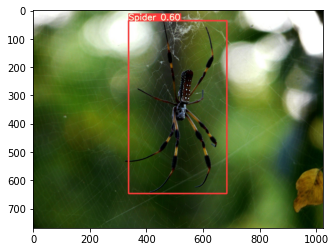

In [65]:
img = cv2.imread("runs/detect/animals/5b9b0b60d04aae25.jpg")
plt.imshow(img[:,:,2::-1]);